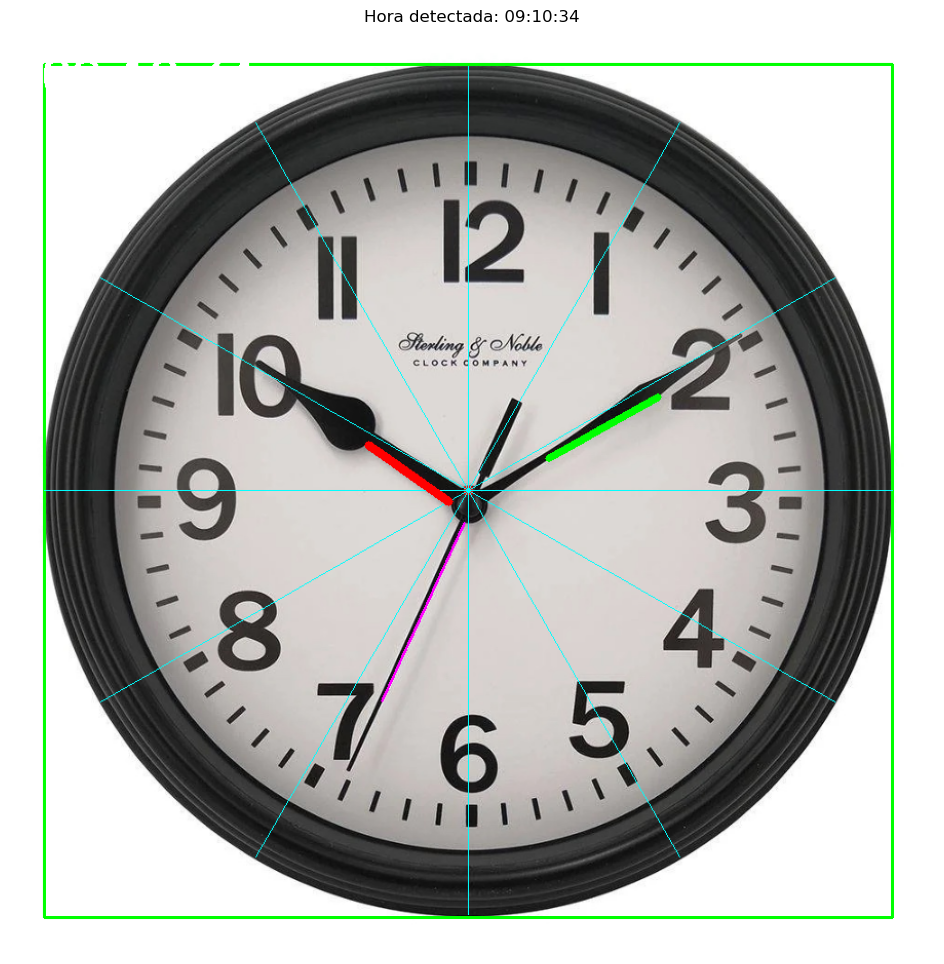

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "reloj.jpg"
SHOW_DEBUG = True
RESIZE = 900

# geometria
def calculate_angle(x, y, cx, cy):
    dx = x - cx
    dy = cy - y
    angle = np.degrees(np.arctan2(dx, dy))
    if angle < 0:
        angle += 360
    return angle

def line_length(x1, y1, x2, y2):
    return np.sqrt(
        (x2 - x1)**2 +
        (y2 - y1)**2
    )
def get_far_endpoint(x1, y1, x2, y2, cx, cy):
    d1 = np.sqrt((x1 - cx)**2 + (y1 - cy)**2)
    d2 = np.sqrt((x2 - cx)**2 + (y2 - cy)**2)
    if d1 > d2:
        return x1, y1, d1
    else:
        return x2, y2, d2

def line_distance_to_center(
    x1, y1,
    x2, y2,
    cx, cy
):
    A = y2 - y1
    B = x1 - x2
    C = x2*y1 - x1*y2
    return abs(
        A*cx + B*cy + C
    ) / np.sqrt(A*A + B*B)

# grosor
def estimate_thickness(
    gray,
    x1, y1,
    x2, y2
):
    length = int(
        line_length(x1,y1,x2,y2)
    )
    if length == 0:
        return 1
    vx = (x2 - x1) / length
    vy = (y2 - y1) / length
    px = -vy
    py = vx
    values = []
    for t in np.linspace(0.25, 0.85, 12):
        sx = int(x1 + (x2-x1)*t)
        sy = int(y1 + (y2-y1)*t)
        count = 0
        for k in range(-12,13):
            xx = int(sx + px*k)
            yy = int(sy + py*k)
            if (
                0 <= xx < gray.shape[1]
                and
                0 <= yy < gray.shape[0]
            ):
                if gray[yy,xx] < 120:
                    count += 1
        values.append(count)
    return np.mean(values)

# conversión
def angle_to_minute(angle):
    return int(round(angle / 6)) % 60

def angle_to_second(angle):
    return int(round(angle / 6)) % 60

def angle_to_hour(angle, minute):
    adjusted = angle - minute * 0.5

    if adjusted < 0:
        adjusted += 360

    hour = int(adjusted / 30)

    if hour == 0:
        hour = 12
    return hour

# cargar imagen
img = cv2.imread("img2.jpeg")

if img is None:
    raise Exception("No se encontró la imagen.")
h, w = img.shape[:2]
scale = RESIZE / max(h, w)
img = cv2.resize(
    img,
    (
        int(w * scale),
        int(h * scale)
    )
)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

blur = cv2.GaussianBlur(
    gray,
    (7,7),
    2
)

# threshold
th = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    5
)

kernel = np.ones((5,5), np.uint8)

th = cv2.morphologyEx(
    th,
    cv2.MORPH_CLOSE,
    kernel
)

# contornos

contours, _ = cv2.findContours(
    th,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if len(contours) == 0:
    raise Exception("No se encontró reloj.")

clock_contour = max(
    contours,
    key=cv2.contourArea
)

x,y,w,h = cv2.boundingRect(
    clock_contour
)

cx = x + w // 2
cy = y + h // 2

radius = int(min(w,h)/2)

# máscara

mask = np.zeros_like(gray)

cv2.circle(
    mask,
    (cx,cy),
    int(radius * 0.92),
    255,
    -1
)

masked = cv2.bitwise_and(
    blur,
    blur,
    mask=mask
)

# bordes

edges = cv2.Canny(
    masked,
    50,
    160
)

# líneas

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=45,
    minLineLength=int(radius * 0.15),
    maxLineGap=20
)

if lines is None:
    raise Exception("No se detectaron líneas.")

candidate_lines = []

for line in lines:

    x1,y1,x2,y2 = line[0]

    length = line_length(
        x1,y1,x2,y2
    )

    if length < radius * 0.18:
        continue

    distance = line_distance_to_center(
        x1,y1,x2,y2,
        cx,cy
    )

    if distance > radius * 0.09:
        continue

    d1 = np.sqrt(
        (x1-cx)**2 +
        (y1-cy)**2
    )

    d2 = np.sqrt(
        (x2-cx)**2 +
        (y2-cy)**2
    )

    if min(d1,d2) > radius * 0.30:
        continue

    fx, fy, flength = get_far_endpoint(
        x1,y1,x2,y2,
        cx,cy
    )

    angle = calculate_angle(
        fx, fy,
        cx, cy
    )

    thickness = estimate_thickness(
        gray,
        x1,y1,x2,y2
    )

    ratio = flength / radius

    candidate_lines.append({

        "line": (
            x1,y1,x2,y2
        ),

        "length": flength,

        "ratio": ratio,

        "angle": angle,

        "thickness": thickness
    })

# clustering angular

clusters = []

ANGLE_THRESHOLD = 5

for line in candidate_lines:

    added = False

    for cluster in clusters:

        diff = abs(
            line["angle"] -
            cluster["mean_angle"]
        )

        diff = min(diff, 360-diff)

        if diff < ANGLE_THRESHOLD:

            cluster["lines"].append(line)

            angles = [
                l["angle"]
                for l in cluster["lines"]
            ]

            cluster["mean_angle"] = np.mean(
                angles
            )

            added = True
            break

    if not added:

        clusters.append({

            "mean_angle":
            line["angle"],

            "lines":
            [line]
        })

# construir agujas

hands = []

for cluster in clusters:

    lines_cluster = cluster["lines"]

    avg_angle = cluster["mean_angle"]

    avg_length = np.mean([
        l["length"]
        for l in lines_cluster
    ])

    avg_ratio = np.mean([
        l["ratio"]
        for l in lines_cluster
    ])

    avg_thickness = np.mean([
        l["thickness"]
        for l in lines_cluster
    ])

    best_line = max(
        lines_cluster,
        key=lambda l: l["length"]
    )

    hands.append({

        "angle":
        avg_angle,

        "length":
        avg_length,

        "ratio":
        avg_ratio,

        "thickness":
        avg_thickness,

        "line":
        best_line["line"],

        "votes":
        len(lines_cluster)
    })

if len(hands) < 3:
    raise Exception(
        "No se detectaron suficientes agujas."
    )

# scores inteligentes

for hand in hands:

    # horario
    # más grueso
    # más corto

    hand["hour_score"] = (

        hand["thickness"] * 6

        -

        hand["ratio"] * 120

        +

        hand["votes"] * 2
    )

    # segundero
    # MÁS LARGO
    # MÁS FINO

    hand["second_score"] = (

        hand["ratio"] * 180

        -

        hand["thickness"] * 7
    )

# horario

hour_hand = max(
    hands,
    key=lambda h: h["hour_score"]
)

remaining = [
    h for h in hands
    if h != hour_hand
]

# segundero

second_hand = max(
    remaining,
    key=lambda h: h["second_score"]
)

remaining = [
    h for h in remaining
    if h != second_hand
]

# minutero

minute_hand = max(
    remaining,
    key=lambda h: h["ratio"]
)

# corrección extra
# si el segundero no es realmente más largo

if minute_hand["ratio"] > second_hand["ratio"]:

    temp = second_hand
    second_hand = minute_hand
    minute_hand = temp

# ángulos

hour_angle = hour_hand["angle"]

minute_angle = minute_hand["angle"]

second_angle = second_hand["angle"]

# tiempo

minute = angle_to_minute(
    minute_angle
)

second = angle_to_second(
    second_angle
)

hour = angle_to_hour(
    hour_angle,
    minute
)

# visualización

output = img_rgb.copy()

cv2.rectangle(
    output,
    (x,y),
    (x+w,y+h),
    (0,255,0),
    2
)

cv2.circle(
    output,
    (cx,cy),
    5,
    (255,0,0),
    -1
)

# sectores

for h_i in range(12):

    angle = np.deg2rad(
        h_i * 30 - 90
    )

    xx = int(
        cx + radius * np.cos(angle)
    )

    yy = int(
        cy + radius * np.sin(angle)
    )

    cv2.line(
        output,
        (cx,cy),
        (xx,yy),
        (0,255,255),
        1
    )

# dibujar agujas

def draw_hand(
    hand,
    color,
    thickness
):

    x1,y1,x2,y2 = hand["line"]

    cv2.line(
        output,
        (x1,y1),
        (x2,y2),
        color,
        thickness
    )

draw_hand(
    hour_hand,
    (255,0,0),
    8
)

draw_hand(
    minute_hand,
    (0,255,0),
    5
)

draw_hand(
    second_hand,
    (255,0,255),
    2
)

# texto

time_text = (
    f"{hour:02}:"
    f"{minute:02}:"
    f"{second:02}"
)

cv2.putText(
    output,
    time_text,
    (30,60),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    (255,255,255),
    3
)

plt.figure(figsize=(12,12))

plt.imshow(output)

plt.title(
    f"Hora detectada: {time_text}"
)

plt.axis("off")

plt.show()